# Projeto de Filtro - $F_c=120 kHz$

Projeto de filtro do sensor de corente, para calcular o valor RMS da corrente foi selecionada a 9ª harmônica como frequência de corte $\left( f_c=9\cdot12 kHz = 108 kHz \right)$

Coeficientes do filtro PB IIR: b = [0.58867513 1.7660254  1.7660254  0.58867513], a = [1.         1.96299092 1.4        0.34641016]


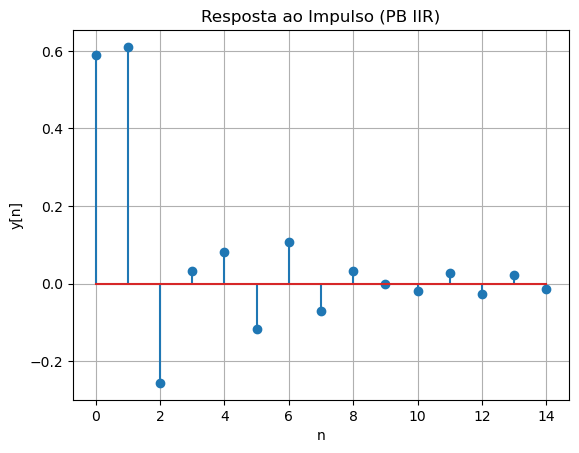

<Figure size 640x480 with 0 Axes>

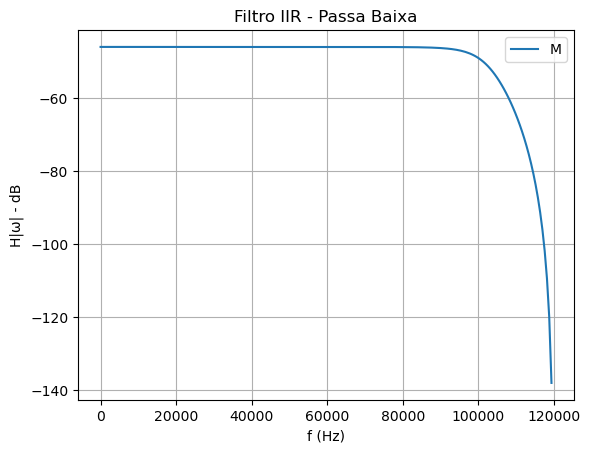

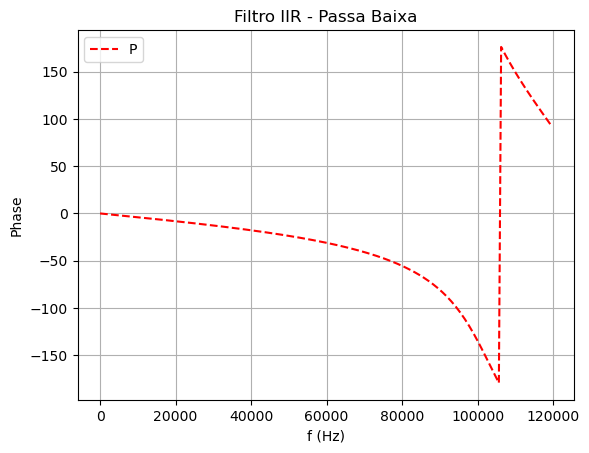

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sp

import DSP

# Projeto do filtro PB IIR
fcB = 100e3    # Analógica
fs  = 240e3    # Sampling -> dobro do atual
[b_PBI, a_PBI] =sp.butter(3, fcB, fs=fs)
print(f"Coeficientes do filtro PB IIR: b = {b_PBI}, a = {a_PBI}")
# Resposta ao impulso
x = np.zeros(400)
x[0] = 1
h_PBI = sp.lfilter(b_PBI, a_PBI, x)
nf = 15 # n em que o sinal aproxima 0
DSP.plot([h_PBI[0:nf], np.arange(0, nf)], title="Resposta ao Impulso (PB IIR)")
DSP.plot_FFT(h_PBI, type= "Separate", T=1/fs, dB=True, title="Filtro IIR - Passa Baixa")

Coeficientes do filtro PB IIR em SOS: [[ 19289  19289      0  32767  18918      0]
 [ 32767     -2  32767  32767 -20133  19660]]
Coeficientes do filtro PB IIR em SOS, normalizado: [[ 5.88671529e-01  5.88671529e-01  0.00000000e+00  1.00000000e+00
   5.77349162e-01  0.00000000e+00]
 [ 1.00000000e+00 -6.10370190e-05  1.00000000e+00  1.00000000e+00
  -6.14429151e-01  5.99993896e-01]]


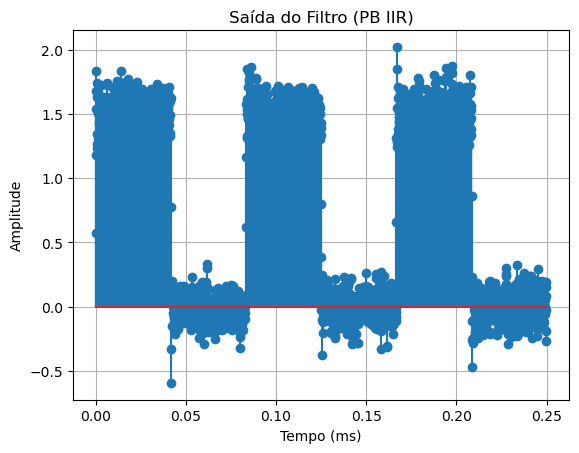

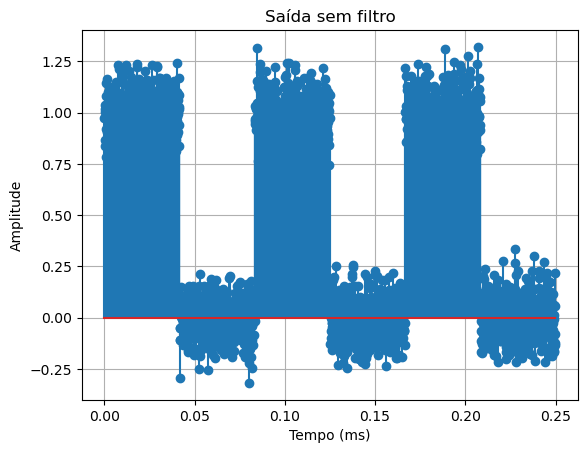

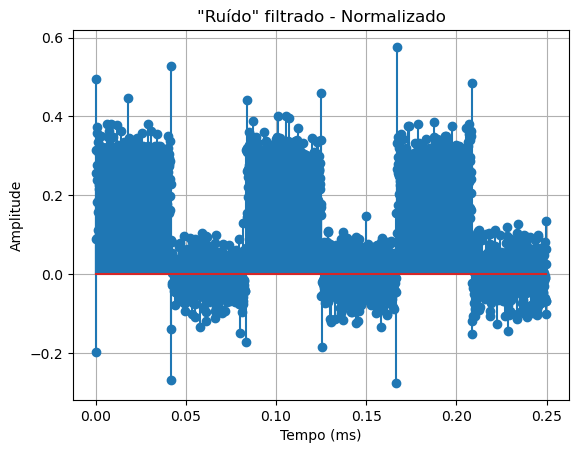

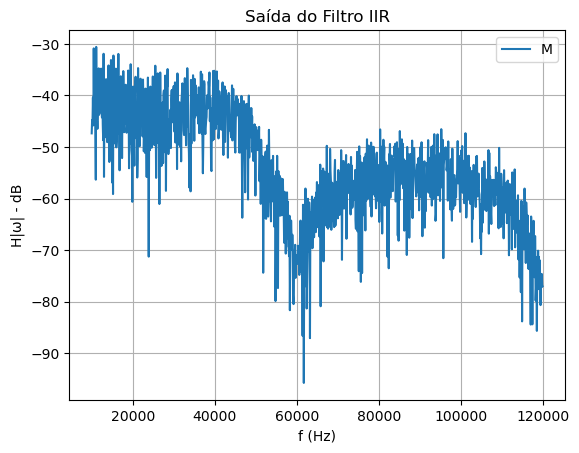

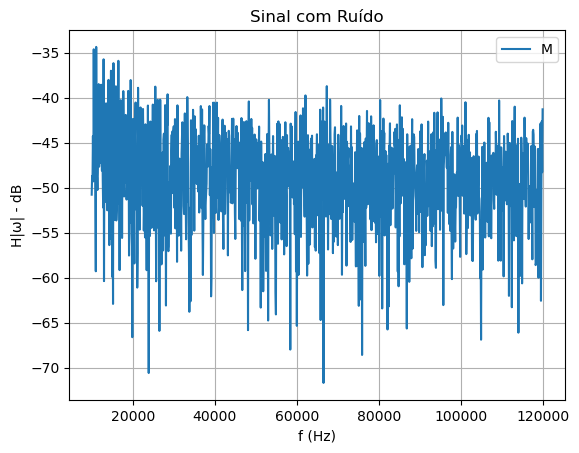

In [4]:
# Filtro em SOS
sos_filter = sp.tf2sos(b_PBI, a_PBI)
scale = 2**15 - 1
sos_int = np.round(sos_filter * scale).astype(np.int16)
print(f"Coeficientes do filtro PB IIR em SOS: {sos_int}")
sos_int = sos_int/scale
# g       = g/scale
print(f"Coeficientes do filtro PB IIR em SOS, normalizado: {sos_int[:]}")
# print(f"Ganho do filtro, normalizado: {g}")
# Generate test signal
t = np.linspace(0, 0.25e-3, 2400, endpoint=False) # 3 Períodos
x = (sp.square(2 * np.pi * 12e3 * t)+1)/2 + np.random.normal(0, 0.1, t.shape)
# Apply using SOS format - sosfilt espera sos_int[:, 3]=1, então dividimos por scale
y = sp.sosfilt(sos_int, x.astype(np.float64))
# y = y/np.max(y)
# x = x/np.max(x)
DSP.plot([y, 1e3*t], title="Saída do Filtro (PB IIR)", xl="Tempo (ms)", yl="Amplitude")
DSP.plot([x, 1e3*t], title="Saída sem filtro", xl="Tempo (ms)", yl="Amplitude")
DSP.plot([(y/np.max(y))-(x/np.max(y)), 1e3*t], title="\"Ruído\" filtrado - Normalizado", xl="Tempo (ms)", yl="Amplitude")
DSP.plot_FFT(y, type= "Mag_Only", T=1/fs, dB=True, title="Saída do Filtro IIR", fmin=10e3, fmax=120e3)
DSP.plot_FFT(x, type= "Mag_Only", T=1/fs, dB=True, title="Sinal com Ruído", fmin=10e3, fmax=120e3)